# Veri Bağlantısı

In [9]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from sqlalchemy.exc import SQLAlchemyError
from dotenv import load_dotenv

In [10]:
#conncetion detail
load_dotenv()
user =  os.getenv("POSTGRES_USER")
password = os.getenv("POSTGRES_PASSWORD")
host = "localhost"
port = os.getenv("POSTGRES_PORT")
database = os.getenv("POSTGRES_DB")

def create_db_engine():
    try:
        engine = create_engine(f"postgresql://{user}:{password}@{host}:{port}/{database}")

        #test connection
        with engine.connect() as conn:
            print("Bağlantı Başarılı")
        return engine

    except SQLAlchemyError as e:
        print("SQLAlchemy hatası:", e)
        return None

    
    

def get_data(query):
    engine = create_db_engine()

    if engine is None:
        return None

    try:
        df = pd.read_sql(query,engine)
        print(f"{query} --> Adresli Veri Çekildi")
        return df
    
    except SQLAlchemyError as e:
        print("Query hatası:", e)
        return None

    except Exception as e:
        print("Genel hata:", e)
        return None


query = """
    SELECT 
        f.rent_euro,
        l.county,
        l.province,
        l.is_dublin,
        p.property_type,
        p.bedrooms,
        t.rent_year
    FROM gold.fact_rent f
    JOIN gold.dim_location l ON f.dim_location_id = l.id
    JOIN gold.dim_property p ON f.dim_property_id = p.id
    JOIN gold.dim_time t ON f.dim_time_id = t.id
"""

df = get_data(query)

if df is not None:
    print(df.head())
    print("\nVeri seti hakkında istatistiksel özet:")
    # İstatistiksel özeti görmek için DataFrame'in describe() fonksiyonunu kullanıyoruz
    print(df.describe())




Bağlantı Başarılı

    SELECT 
        f.rent_euro,
        l.county,
        l.province,
        l.is_dublin,
        p.property_type,
        p.bedrooms,
        t.rent_year
    FROM gold.fact_rent f
    JOIN gold.dim_location l ON f.dim_location_id = l.id
    JOIN gold.dim_property p ON f.dim_property_id = p.id
    JOIN gold.dim_time t ON f.dim_time_id = t.id
 --> Adresli Veri Çekildi
   rent_euro  county  province  is_dublin       property_type      bedrooms  \
0     835.90  carlow  leinster      False  all property types  all bedrooms   
1     860.74  carlow  leinster      False  all property types  all bedrooms   
2     910.91  carlow  leinster      False  all property types  all bedrooms   
3     812.14  carlow  leinster      False  all property types  all bedrooms   
4     666.31   cavan    ulster      False  all property types  all bedrooms   

   rent_year  
0       2020  
1       2020  
2       2020  
3       2020  
4       2020  

Veri seti hakkında istatistiksel özet:
    

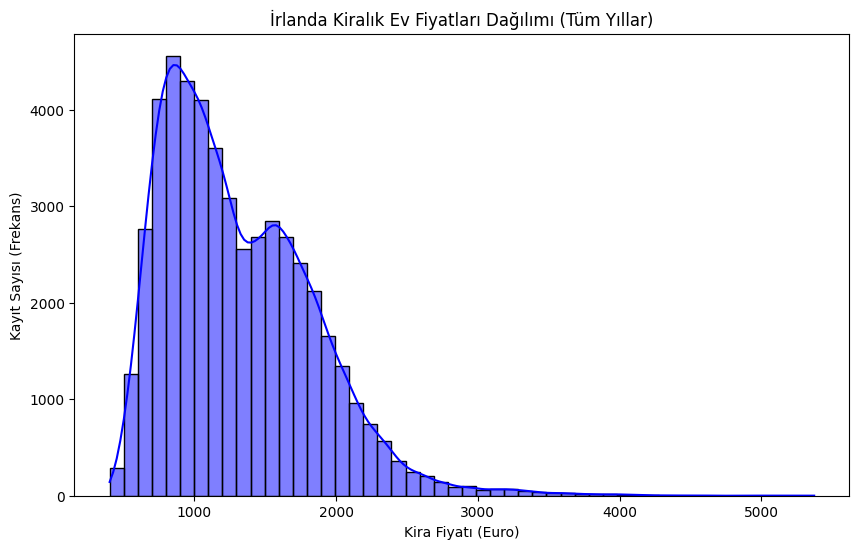

In [11]:
plt.figure(figsize=(10,6))
sns.histplot(data=df,x = "rent_euro", bins = 50 , kde = True , color = "blue")
plt.title('İrlanda Kiralık Ev Fiyatları Dağılımı (Tüm Yıllar)')
plt.xlabel('Kira Fiyatı (Euro)')
plt.ylabel('Kayıt Sayısı (Frekans)')
plt.savefig("C:/Users/karam/Desktop/irish-rent-analysis/figure/ireland_rental_price_distribution.png")
plt.show()

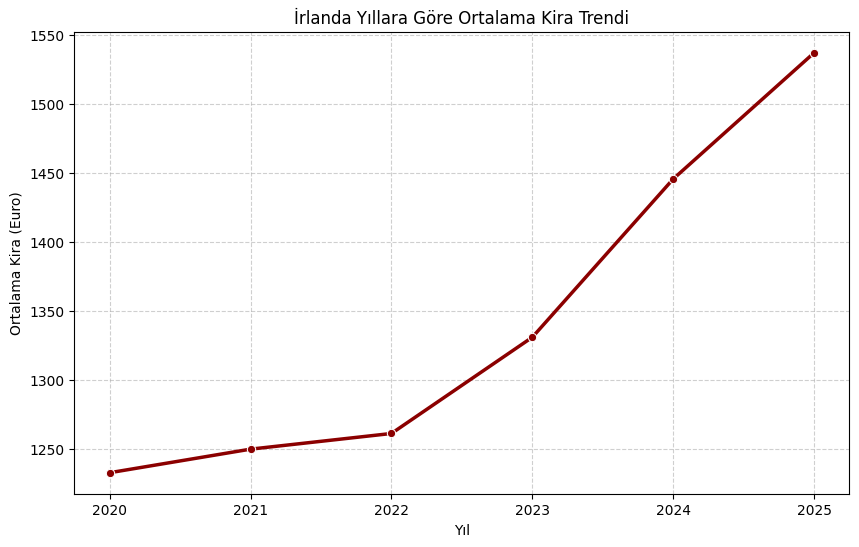

In [16]:
yearly_avg_rent = df.groupby("rent_year")["rent_euro"].mean().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=yearly_avg_rent, x="rent_year" , y="rent_euro" , marker = "o" , linewidth = 2.5 , color = "darkred" )
plt.title('İrlanda Yıllara Göre Ortalama Kira Trendi')
plt.xlabel('Yıl')
plt.ylabel('Ortalama Kira (Euro)')
# X eksenindeki yılların ondalıklı (örn: 2010.5) değil, tam sayı görünmesini sağlayalım
plt.xticks(yearly_avg_rent['rent_year'].astype(int))
plt.grid(True, linestyle='--', alpha=0.6) # Arka plana ızgara eklersek okuması kolaylaşır
plt.savefig("C:/Users/karam/Desktop/irish-rent-analysis/figure/ireland_rent_trend_over_time.png")
plt.show()

C:\Users\karam\AppData\Local\Temp\ipykernel_18760\27599554.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df , x = "is_dublin" , y="rent_euro" , palette = "Set2")


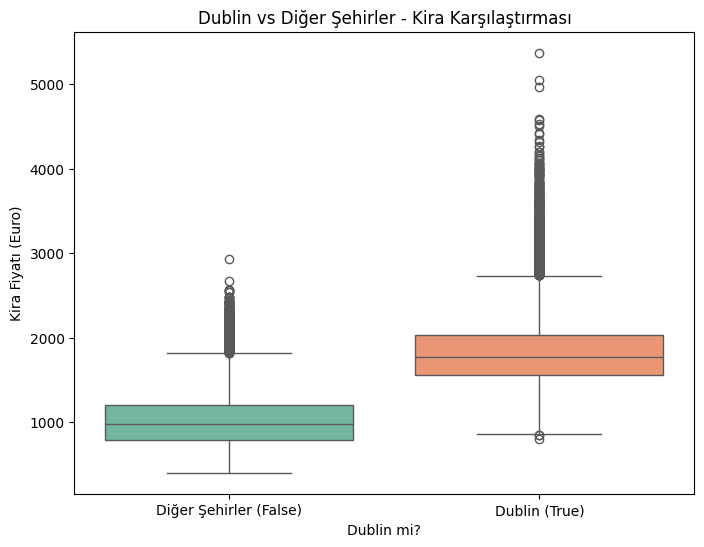

Bölgelere Göre Ortalama Kiralar:
is_dublin
False    1023.444515
True     1831.133811
Name: rent_euro, dtype: float64


In [17]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df , x = "is_dublin" , y="rent_euro" , palette = "Set2")
plt.title('Dublin vs Diğer Şehirler - Kira Karşılaştırması')
plt.xlabel('Dublin mi?')
plt.ylabel('Kira Fiyatı (Euro)')
# Eksen yazısını daha okunabilir yapalım (True/False yerine isim yazalım)
plt.xticks(ticks=[0, 1], labels=['Diğer Şehirler (False)', 'Dublin (True)'])
plt.savefig("C:/Users/karam/Desktop/irish-rent-analysis/figure/dublin_vs_other_cities_rent_comparison.png")
plt.show()
# İstersen rakamsal olarak da ortalamaları görelim:
print("Bölgelere Göre Ortalama Kiralar:")
print(df.groupby('is_dublin')['rent_euro'].mean())

C:\Users\karam\AppData\Local\Temp\ipykernel_18760\693878618.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df , x="property_type" , y="rent_euro" , palette = "viridis" , ci=None)
C:\Users\karam\AppData\Local\Temp\ipykernel_18760\693878618.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df , x="property_type" , y="rent_euro" , palette = "viridis" , ci=None)


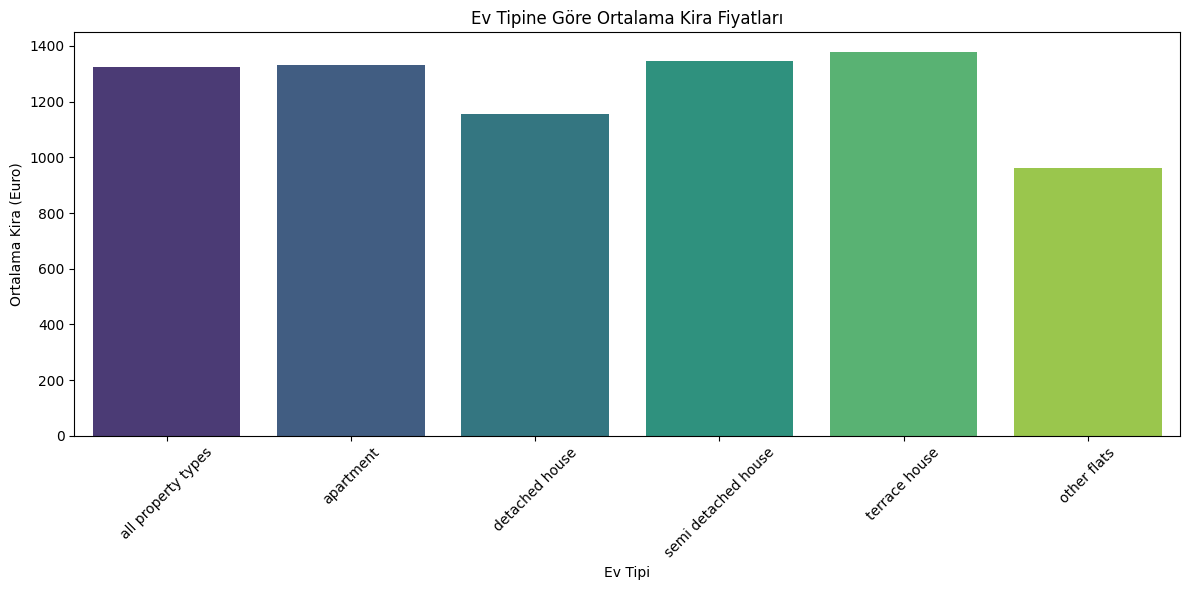

Oda Sayısına Göre Ortalama Kiralar:
bedrooms
four plus bed    1625.645476
three bed        1375.590421
all bedrooms     1341.315925
two bed          1316.781674
1 to 3 bed       1269.925116
1 to 2 bed       1212.097287
one bed          1098.301603
Name: rent_euro, dtype: float64


In [19]:
plt.figure(figsize=(12,6))
sns.barplot(data=df , x="property_type" , y="rent_euro" , palette = "viridis" , ci=None)
plt.title('Ev Tipine Göre Ortalama Kira Fiyatları')
plt.xlabel('Ev Tipi')
plt.ylabel('Ortalama Kira (Euro)')
# X eksenindeki yazılar (Apartment, House vb.) uzunsa üst üste binmesin diye 45 derece eğik yazıyoruz
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("C:/Users/karam/Desktop/irish-rent-analysis/figure/average_rent_by_property_type.png")
plt.show()
# Ekstra: Oda sayısına göre ortalama kiraya rakamsal olarak bakalım:
print("Oda Sayısına Göre Ortalama Kiralar:")
print(df.groupby('bedrooms')['rent_euro'].mean().sort_values(ascending=False))